# Scenario-specific performance analysis

In [1]:
import torch
from scipy.special import softmax

def load_params(model_path, weights_only=False):
    # 1) Load parameters
    model_data = torch.load(model_path, map_location=torch.device('cpu'), weights_only=weights_only)
    theta = model_data['theta']          # shape: (n_people, k)
    d = model_data['d']                  # shape: (n_items,  k)
    p = model_data['phi']

    print("--- Initial Loaded Data ---")
    print(f"Original theta shape: {theta.shape}")
    print(f"Original 'd' matrix shape: {d.shape}\n")

    d_numpy = d.detach().cpu().numpy()
    theta_numpy = theta.detach().cpu().numpy()
    p_numpy = p.detach().cpu().numpy()
    w_numpy = softmax(p_numpy, axis=1)
    return d_numpy, theta_numpy, p_numpy, w_numpy

In [2]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
sys.path.append('..')
import style
# Concatenate math and gsm outputs for theta, a, b

d, theta, p, w = load_params('../result/lada-fitting-joint/lada_joint_k2_legalbench.pt', weights_only=False)

resmat = pd.read_pickle('../data-reeval-multi/resmat.pkl')

conv = ['legalbench']
conv_mask = resmat.loc[:, resmat.columns.get_level_values("scenario").isin(conv)]

conv_questions = conv_mask.columns.get_level_values('input.text').tolist()

answers_path = Path('../data-processing/legalbench/legalbench_result.pkl')
if not answers_path.exists():
    raise FileNotFoundError(f'Expected answer key at {answers_path} was not found. Run the assembly script first.')
answer_df = pd.read_pickle(answers_path)
answer_frame = answer_df.loc['answer'].rename('answer').reset_index()
type_frame = answer_df.loc['type'].rename('type').reset_index()
answer_frame['scenario'] = answer_frame['scenario'].astype(str).str.lower()
type_frame['scenario'] = type_frame['scenario'].astype(str).str.lower()
merged_answers = answer_frame.merge(
    type_frame[['scenario', 'input.text', 'type']],
    on=['scenario', 'input.text'],
    how='left'
 )
answer_map = merged_answers[merged_answers['scenario'] == 'legalbench'].set_index('input.text')[['answer', 'type']]
answers_aligned = answer_map.reindex(conv_questions)
if answers_aligned['answer'].isna().any() or answers_aligned['type'].isna().any():
    missing_answers = answers_aligned[answers_aligned['answer'].isna()].index.tolist()
    missing_types = answers_aligned[answers_aligned['type'].isna()].index.tolist()
    raise ValueError(
        'Missing answers or types for prompts. '
        f'Missing answers: {missing_answers[:5]} | Missing types: {missing_types[:5]}'
    )

theta_df = pd.DataFrame(theta, columns=[f'Factor_{i+1}' for i in range(theta.shape[1])], index=resmat.index)
w_df = pd.DataFrame(w, columns=[f'Factor_{i+1}' for i in range(w.shape[1])])
w_df['question'] = conv_questions
w_df['answer'] = answers_aligned['answer'].values
w_df['type'] = answers_aligned['type'].values

models_answered = conv_mask.dropna(how='all').index.tolist()
accuracy = (conv_mask.sum(axis=1) / conv_mask.notnull().sum(axis=1)).loc[models_answered]
theta_irt = pd.read_csv('../result/irt-fitting/calibration_result_theta_legalbench.csv')
theta_df = theta_df.loc[models_answered]
theta_df['accuracy'] = accuracy
theta_df['irt'] = theta_irt.values

--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 2])
Original 'd' matrix shape: torch.Size([1997])



In [3]:
import pandas as pd

model_spec = pd.read_csv('../data-reeval-multi/model_specs.csv')
model_spec.dropna(subset=['size'], inplace=True)
model_spec.sort_values(by='size', ascending=False, inplace=True)
model_spec_llama = model_spec[model_spec['code'].str.contains('meta/', case=False, na=False)]

print(f"Model spec shape: {model_spec.shape}")
model_spec.head()

Model spec shape: (118, 5)


,code,name,size,pretrain,flops
42,microsoft/TNLGv2_530B,TNLG v2 (530B),530.0,0.27,143.1
115,snowflake/snowflake-arctic-instruct,Arctic Instruct,480.0,0.40,768.0
163,meta/llama-3.1-405b-instruct-turbo,Llama 3.1 Instruct Turbo (405B),405.0,15.00,36450.0
52,ai21/j2-jumbo,Jurassic-2 Jumbo (178B),178.0,1.20,213.6
50,ai21/j1-jumbo,J1-Jumbo v1 (178B),178.0,0.30,53.4


In [4]:
# Prepare theta scores with EAP estimates
theta_score_df = theta_df.rename(columns={'Factor_1': 'f1', 'Factor_2': 'f2'}).copy()
theta_score_df['accuracy'] = accuracy
theta_score_df['irt'] = theta_irt.values
theta_score_df.dropna(how='any', inplace=True)
theta_score_df = theta_score_df.round(6)

print(f"Theta score DataFrame shape: {theta_score_df.shape}")
theta_score_df.head()

Theta score DataFrame shape: (91, 4)


,f1,f2,accuracy,irt
request.model,,,,
allenai/olmo-7b,0.098950,-1.509060,0.386079,-1.071928
cohere/command-light,2.073788,-3.330914,0.410115,-0.945389
AlephAlpha/luminous-base,1.562983,-2.791275,0.406610,-0.982251
cohere/command,-1.205221,0.806234,0.505258,-0.348166
mistralai/mistral-7b-instruct-v0.3,-1.696037,-0.140001,0.377066,-1.153409


In [5]:
# Calculate Linear Predictor: L = d + W^T * theta
# For each model, compute the average linear predictor across all items

# Get the factor loadings (W) and difficulties (d) for the first 2 factors
w_params = w_df[['Factor_1', 'Factor_2']].values  # (n_items, 2)
d_params = d[:, :2] if d.ndim > 1 else d.reshape(-1, 1)[:, :2]  # (n_items, 2)

# For each model, calculate the linear predictor for each item, then average
linear_predictors = []
for model_idx in theta_score_df.index:
    if model_idx in theta_df.index:
        # Get theta for this model (2 factors)
        theta_model = theta_df.loc[model_idx, ['Factor_1', 'Factor_2']].values  # (2,)
        
        # Calculate L = d + W^T * theta for all items
        # W^T * theta: (n_items, 2) @ (2,) = (n_items,)
        linear_pred_items = d_params.sum(axis=1) + (w_params @ theta_model)
        
        # Average across all items to get a single score for this model
        avg_linear_pred = linear_pred_items.mean()
        linear_predictors.append(avg_linear_pred)
    else:
        linear_predictors.append(np.nan)

theta_score_df['linear_pred'] = linear_predictors

print(f"Linear predictor statistics:")
print(theta_score_df['linear_pred'].describe())

Linear predictor statistics:
count    91.000000
mean      0.240369
std       0.595699
min      -1.407006
25%      -0.129054
50%       0.413862
75%       0.672540
max       1.114247
Name: linear_pred, dtype: float64


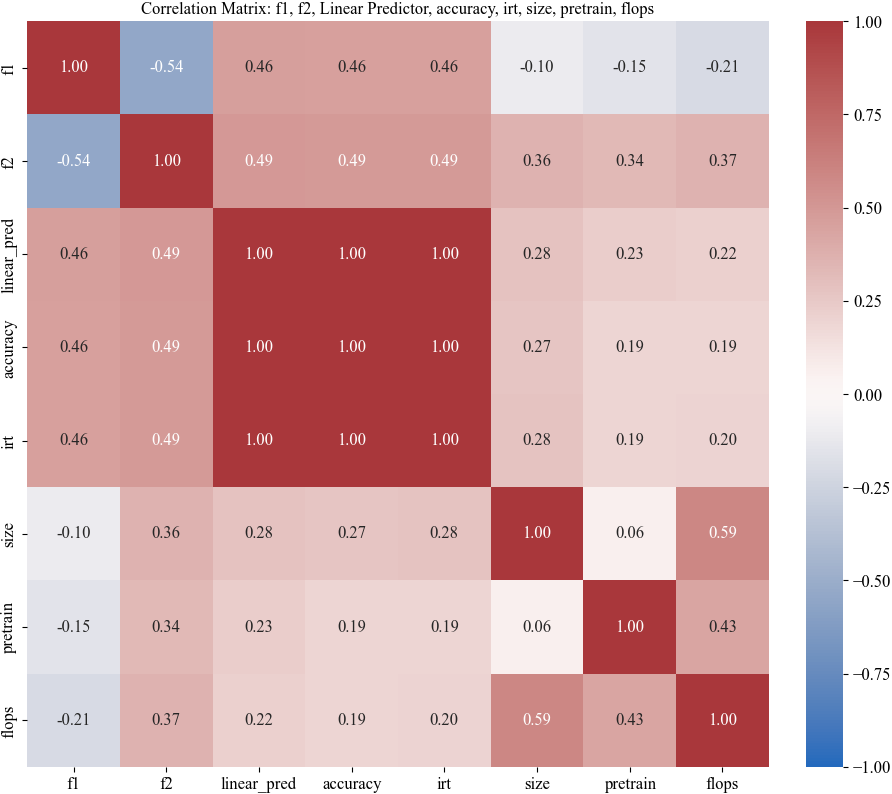

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Join model specs for the extended correlation analysis
model_score_df = theta_score_df.join(model_spec.set_index("code"), how="left")

# Select relevant columns including the new linear predictor
corr_cols_extended = ['f1', 'f2', 'linear_pred', 'accuracy', 'irt', 'size', 'pretrain', 'flops']
corr_extended_df = model_score_df[corr_cols_extended].copy()

# Compute correlation matrix
corr_matrix_extended = corr_extended_df.corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr_matrix_extended, annot=True, cmap='vlag', fmt=".2f", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix: f1, f2, Linear Predictor, accuracy, irt, size, pretrain, flops")
fig.set_constrained_layout(True)
plt.show()

In [7]:
model_score_df.dropna(subset=['f1', 'f2'], inplace=True)
model_score_llama_df = model_score_df.loc[model_score_df.index.str.contains('meta/', case=False, na=False)].copy()

In [8]:
model_score_llama_df.sort_values(by='irt', ascending=False)

,f1,f2,accuracy,irt,linear_pred,name,size,pretrain,flops
request.model,,,,,,,,,
meta/llama-3-70b,1.852748,0.119297,0.709064,1.003420,1.114247,Llama 3 (70B),70.0,15.0,6300.00
meta/llama-3.3-70b-instruct-turbo,-0.589726,1.716840,0.636455,0.534248,0.726390,Llama 3.3 Instruct Turbo (70B),70.0,15.0,635.00
meta/llama-2-70b,1.452699,-0.359598,0.643966,0.530966,0.674100,Llama 2 (70B),70.0,2.0,840.00
meta/llama-3-8b,1.941608,-0.998411,0.619930,0.339373,0.589487,Llama 3 (8B),8.0,15.0,720.00
meta/llama-2-13b,2.024447,-1.288495,0.603906,0.262073,0.482670,Llama 2 (13B),13.0,2.0,156.00
meta/llama-3.1-405b-instruct-turbo,-1.364481,2.087383,0.594392,0.251040,0.534095,Llama 3.1 Instruct Turbo (405B),405.0,15.0,36450.00
meta/llama-3.1-70b-instruct-turbo,-1.222292,2.093483,0.597396,0.229226,0.607074,Llama 3.1 Instruct Turbo (70B),70.0,15.0,6300.00
meta/llama-3.2-90b-vision-instruct-turbo,-1.477635,2.154302,0.590886,0.152692,0.512520,Llama 3.2 Vision Instruct Turbo (90B),90.0,NaN,797.00
meta/llama-2-7b,1.787577,-1.683341,0.542814,-0.118701,0.165459,Llama 2 (7B),7.0,2.0,84.00


In [9]:
model_score_llama_df.columns

Index(['f1', 'f2', 'accuracy', 'irt', 'linear_pred', 'name', 'size',
       'pretrain', 'flops'],
      dtype='object')

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_66044/1725852220.py:56: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


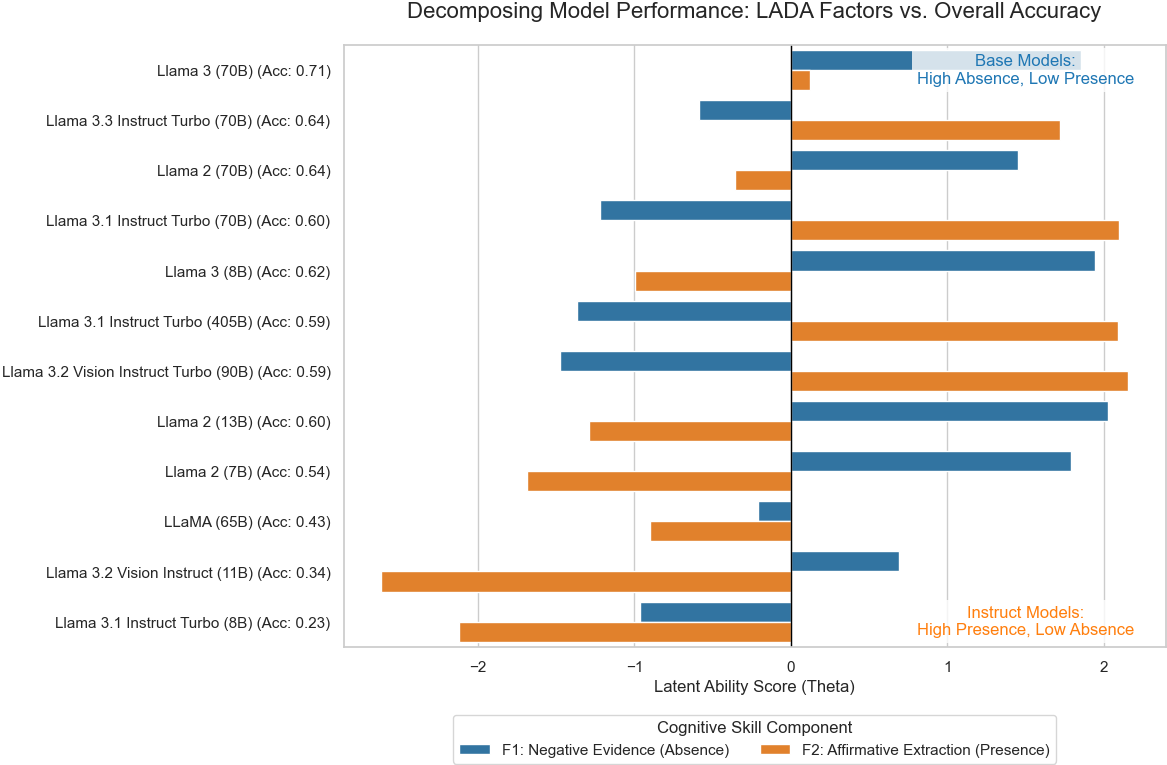

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare Data
# Sort by the Aggregate Metric (Linear Pred is mathematically closer to F1/F2 sum, but Accuracy is more intuitive)
# Let's use Linear Pred for the sort as it represents the LADA composite score directly
plot_df = model_score_llama_df.sort_values('linear_pred', ascending=False).copy()

# Create a clean label with Accuracy included
plot_df['label'] = plot_df.apply(lambda x: f"{x['name']} (Acc: {x['accuracy']:.2f})", axis=1)

# Melt the dataframe to make it suitable for a grouped bar chart
melted_df = plot_df.melt(
    id_vars=['label'], 
    value_vars=['f1', 'f2'], 
    var_name='Factor', 
    value_name='Ability Score (Theta)'
)

# Rename factors for clarity in the legend
melted_df['Factor'] = melted_df['Factor'].map({
    'f1': 'F1: Negative Evidence (Absence)', 
    'f2': 'F2: Affirmative Extraction (Presence)'
})

# 2. Create the Plot
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Draw the bar chart
chart = sns.barplot(
    data=melted_df,
    y='label',
    x='Ability Score (Theta)',
    hue='Factor',
    palette={'F1: Negative Evidence (Absence)': '#1f77b4', 'F2: Affirmative Extraction (Presence)': '#ff7f0e'},
    orient='h'
)

# 3. Add Interpretation Layers
plt.axvline(0, color='black', linewidth=1, linestyle='-') # Zero line
plt.title('Decomposing Model Performance: LADA Factors vs. Overall Accuracy', fontsize=16, pad=20)
plt.xlabel('Latent Ability Score (Theta)', fontsize=12)
plt.ylabel('')
plt.legend(title='Cognitive Skill Component', bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=2)

# Add annotations to highlight the "why"
# (Optional: You can adjust coordinates based on your specific data range)
plt.text(1.5, len(plot_df)-1, "Instruct Models:\nHigh Presence, Low Absence", 
         color='#ff7f0e', ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.text(1.5, 0, "Base Models:\nHigh Absence, Low Presence", 
         color='#1f77b4', ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.show()

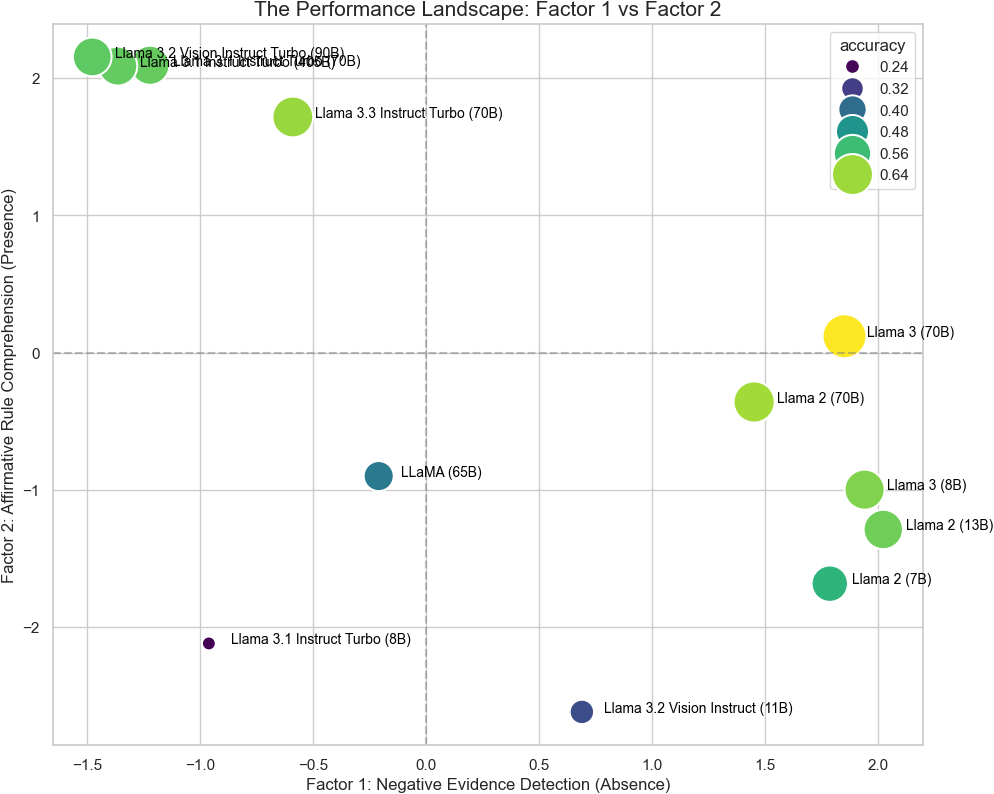

In [11]:
plt.figure(figsize=(10, 8))

# Scatter plot
scatter = sns.scatterplot(
    data=model_score_llama_df,
    x='f1',
    y='f2',
    size='accuracy',
    hue='accuracy',
    sizes=(100, 1000), # Make the bubbles big enough to see
    palette='viridis',
    legend='brief'
)

# Add labels
for line in range(0, model_score_llama_df.shape[0]):
    plt.text(
        model_score_llama_df.f1.iloc[line]+0.1, 
        model_score_llama_df.f2.iloc[line], 
        model_score_llama_df.name.iloc[line], 
        horizontalalignment='left', 
        size='small', 
        color='black'
    )

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('The Performance Landscape: Factor 1 vs Factor 2', fontsize=15)
plt.xlabel('Factor 1: Negative Evidence Detection (Absence)', fontsize=12)
plt.ylabel('Factor 2: Affirmative Rule Comprehension (Presence)', fontsize=12)

plt.show()

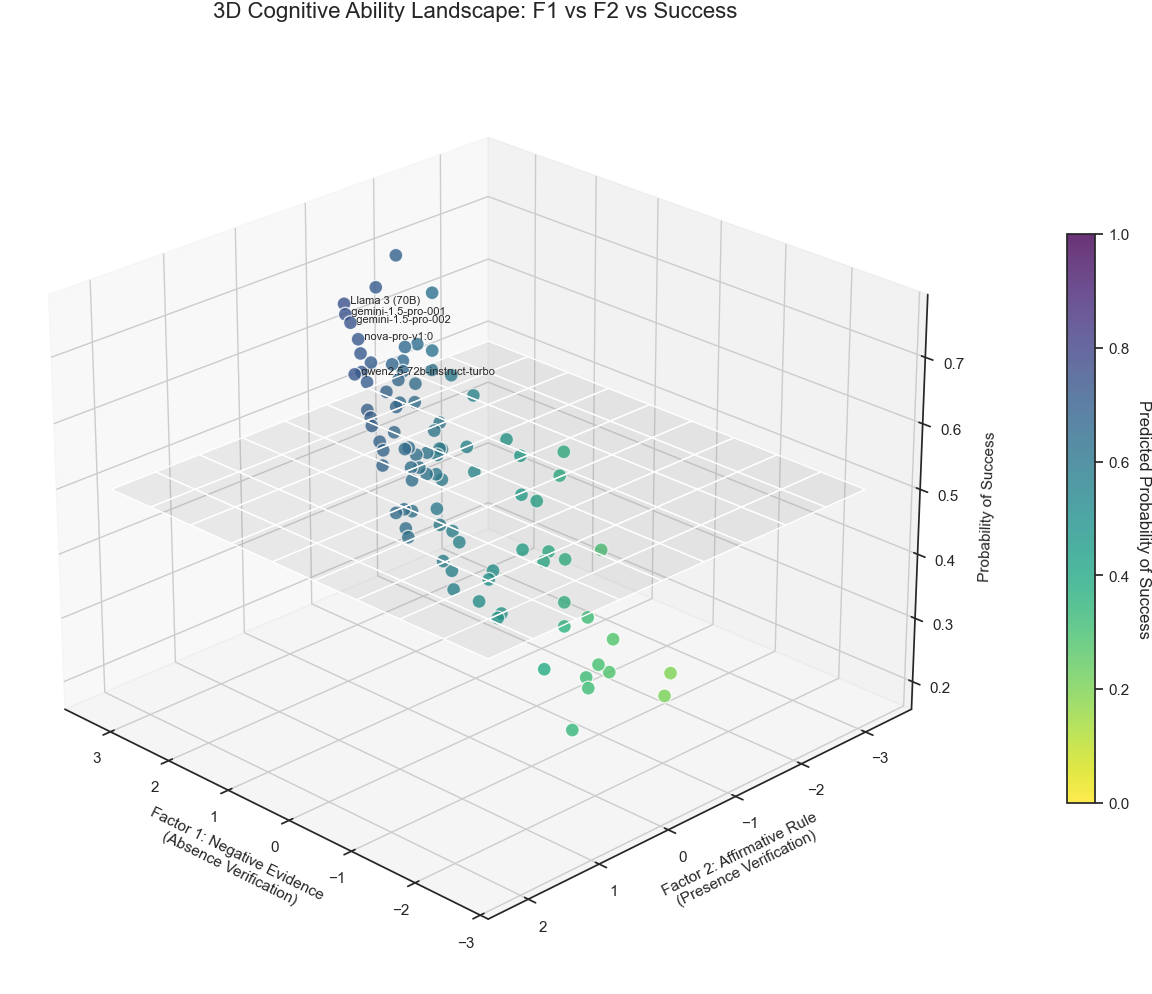

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

# 1. Define Sigmoid Function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 2. Prepare Data
# Create a copy to avoid SettingWithCopy warnings
plot_df = model_score_df.copy()

# Calculate Probability of Success (Z-axis)
plot_df['prob_success'] = sigmoid(plot_df['linear_pred'])

# 3. Setup 3D Plot
fig = plt.figure(figsize=(14, 10), layout='constrained')
ax = fig.add_subplot(111, projection='3d')

# 4. Create Scatter
# X = Factor 1 (Absence)
# Y = Factor 2 (Presence)
# Z = Probability of Success
scatter = ax.scatter(
    plot_df['f1'], 
    plot_df['f2'], 
    plot_df['prob_success'],
    c=plot_df['prob_success'],  # Color by success probability
    cmap='viridis_r',
    s=100,                      # Marker size
    alpha=0.8,                  # Transparency
    edgecolors='w',              # White edges for better visibility
    vmax=1.0,
    vmin=0.0
)

# 5. Add Reference Plane (0.5 Probability)
# This helps visualize which models are "above average" (Prob > 50%)
x_range = np.linspace(plot_df['f1'].min(), plot_df['f1'].max(), 10)
y_range = np.linspace(plot_df['f2'].min(), plot_df['f2'].max(), 10)
X, Y = np.meshgrid(x_range, y_range)
Z = np.full_like(X, 0.5)
ax.plot_surface(X, Y, Z, alpha=0.1, color='gray')

# 6. Labels and Title
ax.set_xlabel('\nFactor 1: Negative Evidence\n(Absence Verification)', fontsize=11)
ax.set_ylabel('\nFactor 2: Affirmative Rule\n(Presence Verification)', fontsize=11)
ax.set_zlabel('\nProbability of Success', fontsize=11)
ax.set_title('3D Cognitive Ability Landscape: F1 vs F2 vs Success', fontsize=16, pad=20)

# Add Colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label('Predicted Probability of Success', rotation=270, labelpad=15)

# 7. Annotate Top Models (Optional)
# Annotate the top 5 models by success probability
top_models = plot_df.nlargest(5, 'prob_success')
for _, row in top_models.iterrows():
    # Handle cases where name is NaN
    if pd.notna(row['name']):
        label = row['name'].split('/')[-1]
    else:
        label = row.name.split('/')[-1]  # Use the index (model code) instead
    
    ax.text(
        row['f1'], row['f2'], row['prob_success'], 
        f"  {label}", 
        fontsize=8, zorder=10
    )

# Set initial viewing angle for best perspective
ax.view_init(elev=25, azim=135)

plt.show()